In [ ]:
# importing libraries
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [23]:
DATASET_PATH = "../Data/Project5_Ag_Crop and weed detection/agri_data/data"

In [24]:
images = [
    f for f in os.listdir(DATASET_PATH)
    if f.endswith(".jpeg")
]

labels = [
    f for f in os.listdir(DATASET_PATH)
    if f.endswith(".txt")
]

print("Images :", len(images))
print("Labels :", len(labels))

Images : 1300
Labels : 1300


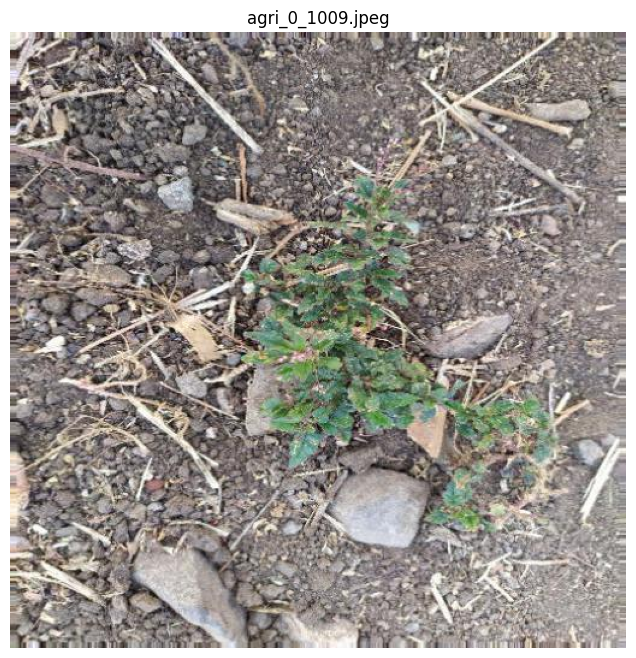

In [ ]:
import cv2
import matplotlib.pyplot as plt
image_path = os.path.join(DATASET_PATH, images[0])
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.title(images[0])
plt.axis("off")
plt.show()

In [ ]:
label_path = os.path.join(DATASET_PATH, labels[0])
with open(label_path, "r") as f:
    lines = f.readlines()
print("Label File:", labels[0])
for line in lines:
    print(line.strip())

Label File: agri_0_1009.txt
1 0.608398 0.498047 0.541016 0.531250


In [ ]:
image_height, image_width = image.shape[:2]
for line in lines:
    cls, x_center, y_center, width, height = map(float, line.split())
    x_center *= image_width
    y_center *= image_height
    width *= image_width
    height *= image_height
    print("Class:", int(cls))
    print("X Center:", x_center)
    print("Y Center:", y_center)
    print("Width:", width)
    print("Height:", height)
    print("-"*30)

Class: 1
X Center: 311.499776
Y Center: 255.000064
Width: 277.000192
Height: 272.0
------------------------------


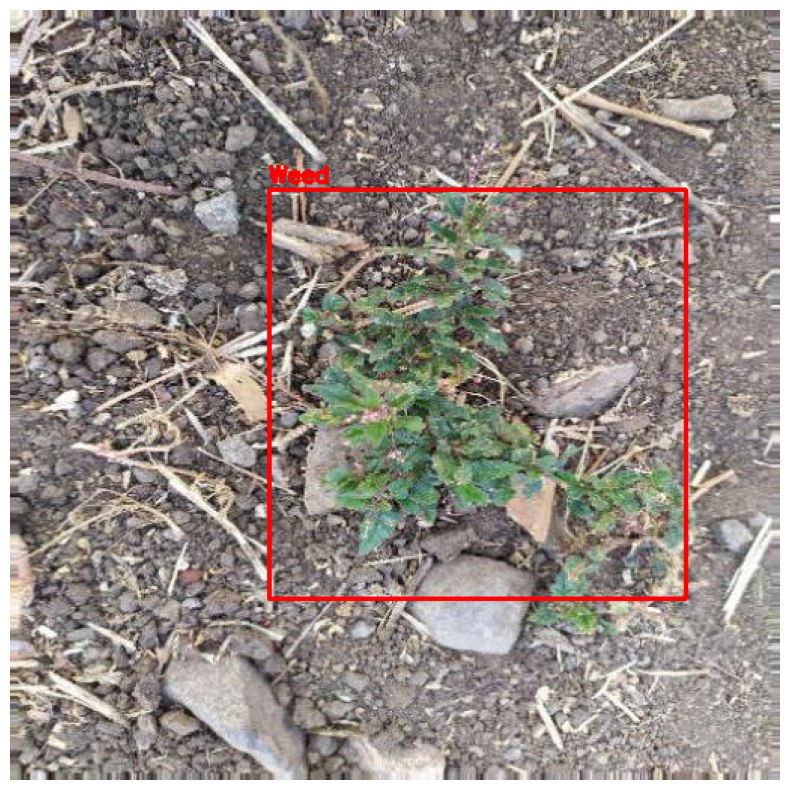

In [29]:
image_copy = image.copy()
for line in lines:
    cls, x_center, y_center, width, height = map(float, line.split())

    x_center *= image_width
    y_center *= image_height
    width *= image_width
    height *= image_height

    x1 = int(x_center - width / 2)
    y1 = int(y_center - height / 2)

    x2 = int(x_center + width / 2)
    y2 = int(y_center + height / 2)

    # Green = Crop
    # Red = Weed

    if int(cls) == 0:
        color = (0,255,0)
        label = "Crop"
    else:
        color = (255,0,0)
        label = "Weed"

    cv2.rectangle(image_copy,(x1,y1),(x2,y2),color,2)

    cv2.putText(
        image_copy,
        label,
        (x1,y1-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(image_copy)
plt.axis("off")
plt.show()

In [30]:
import os
import random
import shutil
from pathlib import Path

SOURCE = Path(DATASET_PATH)

PROJECT = Path("../Data")

train_img = PROJECT/"train"/"images"
train_lbl = PROJECT/"train"/"labels"

val_img = PROJECT/"valid"/"images"
val_lbl = PROJECT/"valid"/"labels"

for p in [train_img, train_lbl, val_img, val_lbl]:
    p.mkdir(parents=True, exist_ok=True)

images = list(SOURCE.glob("*.jpeg"))

random.seed(42)
random.shuffle(images)

split = int(len(images)*0.8)

train = images[:split]
valid = images[split:]

for img in train:

    shutil.copy(img, train_img/img.name)

    shutil.copy(
        img.with_suffix(".txt"),
        train_lbl/(img.stem+".txt")
    )

for img in valid:

    shutil.copy(img, val_img/img.name)

    shutil.copy(
        img.with_suffix(".txt"),
        val_lbl/(img.stem+".txt")
    )

print("Done!")
print("Training Images:",len(train))
print("Validation Images:",len(valid))

Done!
Training Images: 1040
Validation Images: 260


In [31]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Kulde\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [33]:
model.train(
    data="../Data/data.yaml",
    epochs=20,
    imgsz=512
)

Ultralytics 8.4.86  Python-3.13.5 torch-2.12.1+cpu CPU (AMD Ryzen 7 7840HS w/ Radeon 780M Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../Data/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000174AAC47610>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

In [37]:
import os

print("train:", os.listdir("runs/detect/train"))
print("train-2:", os.listdir("runs/detect/train-2"))

train: ['args.yaml', 'weights']
train-2: ['args.yaml', 'BoxF1_curve.png', 'BoxPR_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'labels.jpg', 'results.csv', 'results.png', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg', 'train_batch650.jpg', 'train_batch651.jpg', 'train_batch652.jpg', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg', 'weights']


In [40]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-2/weights/best.pt")

In [45]:
import os

test_image = os.path.join(DATASET_PATH, images[0])

print(test_image)

../Data/Project5_Ag_Crop and weed detection/agri_data/data\..\Data\Project5_Ag_Crop and weed detection\agri_data\data\agri_0_9088.jpeg


In [49]:
import os

images = [
    f for f in os.listdir(DATASET_PATH)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

test_image = os.path.join(DATASET_PATH, images[0])

print(test_image)
print(os.path.exists(test_image))

../Data/Project5_Ag_Crop and weed detection/agri_data/data\agri_0_1009.jpeg
True


In [50]:
results = model.predict(
    source=test_image,
    save=True,
    conf=0.25
)


image 1/1 k:\data\Cd\ML\UpSkill\Crop & Weed Detection using YOLO\Notebook\..\Data\Project5_Ag_Crop and weed detection\agri_data\data\agri_0_1009.jpeg: 512x512 1 weed, 59.3ms
Speed: 2.9ms preprocess, 59.3ms inference, 5.2ms postprocess per image at shape (1, 3, 512, 512)
Results saved to K:\data\Cd\ML\UpSkill\Crop & Weed Detection using YOLO\Notebook\runs\detect\predict


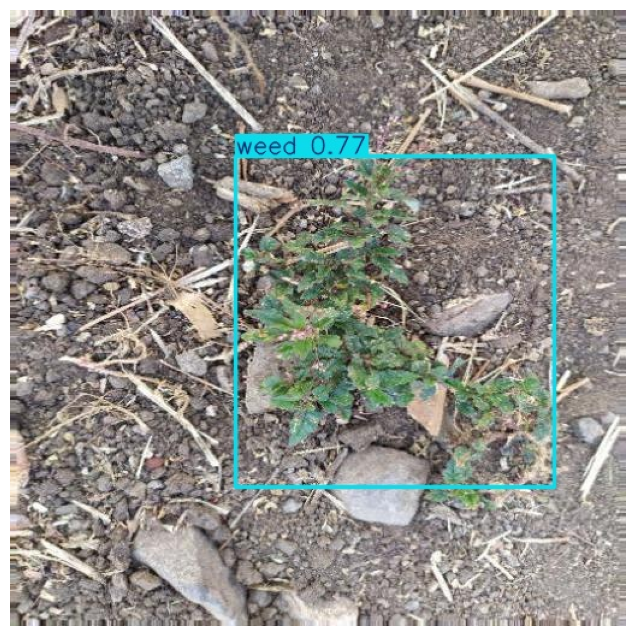

In [57]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/predict/agri_0_1009.jpg")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [59]:
import os

print("Original:", os.path.getsize("runs/detect/train-2/weights/best.pt"))
print("Copied:", os.path.getsize("Models/best.pt"))

Original: 6227946


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Models/best.pt'

In [61]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-2/weights/best.pt")
print("Model loaded successfully!")

Model loaded successfully!
